In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import time
import requests
import xml.etree.ElementTree as ET

# ============================================
# CONFIG
# ============================================

APIKEY = "e6de3d2431"

VOTES_TSV_PATH = "/content/drive/MyDrive/Capstone/votes.tsv"

LIMIT_URBAN = 400
LIMIT_LANDSCAPE = 400

URBAN_DIR = "/content/drive/MyDrive/Capstone/urban_400"
LANDSCAPE_DIR = "/content/drive/MyDrive/Capstone/landscape_400"

URBAN_TSV = "/content/drive/MyDrive/Capstone/urban_400.tsv"
LANDSCAPE_TSV = "/content/drive/MyDrive/Capstone/landscape_400.tsv"

SLEEP_SEC = 0.3


# ============================================
# API CALL
# ============================================

def get_pic_details(photo_id):
    api_url = f"https://api.geograph.org.uk/api/photo/{photo_id}/{APIKEY}"

    try:
        r = requests.get(api_url, timeout=20)
        if r.status_code == 200:
            return r.text
        print("API error:", r.status_code, "for photo_id:", photo_id)
    except Exception as e:
        print("API request failed for", photo_id, ":", e)

    return ""


# ============================================
# SAVE IMAGE
# ============================================

def save_image_to_local(img_url, save_path):
    try:
        r = requests.get(img_url, timeout=30)
        if r.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(r.content)
            return True
        else:
            print("Image download failed with status:", r.status_code)
    except Exception as e:
        print("Image download error:", e)

    return False


# ============================================
# READ votes.tsv
# ============================================

def get_image_paths():
    table = {}

    with open(VOTES_TSV_PATH, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            data = line.split("\t")

            if len(data) < 2:
                continue

            img_id = data[0].strip()
            last_col = data[-1].strip()

            if "http" not in last_col:
                continue

            photo_id = last_col.split("/")[-1]
            table[img_id] = photo_id

    return table


# ============================================
# CLASSIFY IMAGE TYPE
# ============================================

def classify_image_type(category_text):
    cat = (category_text or "").lower()

    landscape_keywords = [
        "landscape", "coast", "mountain", "river", "lake", "forest",
        "countryside", "valley", "hill", "nature", "beach", "park",
        "garden", "field", "moor", "cliff"
    ]

    urban_keywords = [
        "building", "buildings", "city", "urban", "street", "road",
        "architecture", "church", "tower", "house", "houses",
        "bridge", "station", "office", "castle", "cathedral"
    ]

    for w in landscape_keywords:
        if w in cat:
            return "landscape"

    for w in urban_keywords:
        if w in cat:
            return "urban"

    return "other"


# ============================================
# MAIN PROGRAM
# ============================================

def main():
    print("Starting download for 400 urban and 400 landscape images...")

    os.makedirs(URBAN_DIR, exist_ok=True)
    os.makedirs(LANDSCAPE_DIR, exist_ok=True)

    images = get_image_paths()
    print("Total rows in dataset:", len(images))

    urban_count = 0
    landscape_count = 0

    with open(URBAN_TSV, "w", encoding="utf-8") as urban_out, \
         open(LANDSCAPE_TSV, "w", encoding="utf-8") as landscape_out:

        urban_out.write("image_id\tcategory\timage_type\tphoto_id\n")
        landscape_out.write("image_id\tcategory\timage_type\tphoto_id\n")

        for img_id, photo_id in images.items():

            if urban_count >= LIMIT_URBAN and landscape_count >= LIMIT_LANDSCAPE:
                break

            xml_text = get_pic_details(photo_id)
            if not xml_text:
                continue

            try:
                root = ET.fromstring(xml_text)
            except Exception:
                continue

            img = root.find("img")
            category = root.findtext("category") or ""

            if img is None:
                continue

            src = img.attrib.get("src", "")
            if not src:
                continue

            img_type = classify_image_type(category)

            # ----------------------------
            # Save urban image
            # ----------------------------
            if img_type == "urban" and urban_count < LIMIT_URBAN:
                save_path = os.path.join(URBAN_DIR, f"{img_id}.jpg")
                ok = save_image_to_local(src, save_path)

                if ok:
                    urban_count += 1
                    urban_out.write(f"{img_id}\t{category}\t{img_type}\t{photo_id}\n")
                    print(f"Urban downloaded: {urban_count}")

            # ----------------------------
            # Save landscape image
            # ----------------------------
            elif img_type == "landscape" and landscape_count < LIMIT_LANDSCAPE:
                save_path = os.path.join(LANDSCAPE_DIR, f"{img_id}.jpg")
                ok = save_image_to_local(src, save_path)

                if ok:
                    landscape_count += 1
                    landscape_out.write(f"{img_id}\t{category}\t{img_type}\t{photo_id}\n")
                    print(f"Landscape downloaded: {landscape_count}")

            time.sleep(SLEEP_SEC)

    print("\nDone")
    print("Urban downloaded:", urban_count)
    print("Landscape downloaded:", landscape_count)
    print("Urban images folder:", URBAN_DIR)
    print("Landscape images folder:", LANDSCAPE_DIR)
    print("Urban metadata file:", URBAN_TSV)
    print("Landscape metadata file:", LANDSCAPE_TSV)


# ============================================

main()

Starting download for 400 urban and 400 landscape images...
Total rows in dataset: 212212
Landscape downloaded: 1
Urban downloaded: 1
Landscape downloaded: 2
Urban downloaded: 2
Landscape downloaded: 3
Landscape downloaded: 4
Landscape downloaded: 5
Landscape downloaded: 6
Urban downloaded: 3
Landscape downloaded: 7
Urban downloaded: 4
Landscape downloaded: 8
Urban downloaded: 5
Landscape downloaded: 9
Landscape downloaded: 10
Landscape downloaded: 11
Landscape downloaded: 12
Urban downloaded: 6
Urban downloaded: 7
Urban downloaded: 8
Urban downloaded: 9
Urban downloaded: 10
Urban downloaded: 11
Landscape downloaded: 13
Landscape downloaded: 14
Urban downloaded: 12
Landscape downloaded: 15
Landscape downloaded: 16
Urban downloaded: 13
Landscape downloaded: 17
Landscape downloaded: 18
Urban downloaded: 14
Landscape downloaded: 19
Landscape downloaded: 20
Landscape downloaded: 21
Landscape downloaded: 22
Landscape downloaded: 23
Landscape downloaded: 24
Landscape downloaded: 25
Urban dow

# SAM Feature Extraction + Attractiveness Analysis
Integrates Meta's Segment Anything Model (SAM) with Claude scores & human ratings to predict attractiveness.

> **Before running:** uncomment and run the install cell below, then restart the runtime.

In [3]:
# Uncomment and run once, then restart runtime
# !pip install git+https://github.com/facebookresearch/segment-anything.git
# !pip install opencv-python pycocotools matplotlib scikit-learn scipy
# !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth


## Step 0 — Mount Drive & Imports

In [3]:
# ── Step 0: Install dependencies ────────────────────────────
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python pycocotools matplotlib
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from scipy import stats
from scipy.spatial import ConvexHull
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-ypkqvkjo
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-ypkqvkjo
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=8a88323bea5833313d0fe6a3930192eab3e812b5247c2164e1292e8043d2c104
  Stored in directory: /tmp/pip-ephem-wheel-cache-arnh38d_/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything
Mounted at /content/drive


In [4]:
!pip install segment-anything

## Configuration — Paths & Device

In [5]:
# ── CONFIG ───────────────────────────────────────────────────
URBAN_DIR     = "/content/drive/MyDrive/Capstone/urban_400"
LANDSCAPE_DIR = "/content/drive/MyDrive/Capstone/landscape_400"
CLAUDE_CSV    = "/content/drive/MyDrive/Capstone/all_images_15_properties.csv"
VOTES_TSV     = "/content/drive/MyDrive/Capstone/votes.tsv"
SAM_CKPT      = "/content/sam_vit_h_4b8939.pth"
SAM_FEATURES_CACHE = "/content/drive/MyDrive/Capstone/sam_features.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## Step 1 — Load SAM Model

In [6]:
# ── Step 1: Load SAM model ───────────────────────────────────
sam = sam_model_registry["vit_h"](checkpoint=SAM_CKPT)
sam.to(device=DEVICE)

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=16,          # lower = faster, still good coverage
    pred_iou_thresh=0.88,
    stability_score_thresh=0.95,
    min_mask_region_area=500,    # ignore tiny noise segments
)

## Step 2 — SAM Feature Extraction Functions

In [7]:
# ── Step 2: Feature extraction from SAM masks ────────────────

def compute_compactness(mask):
    """4π·area / perimeter² — 1.0 = perfect circle, lower = irregular"""
    contours, _ = cv2.findContours(mask.astype(np.uint8),
                                   cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0.0
    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perim = cv2.arcLength(cnt, True)
    if perim == 0:
        return 0.0
    return (4 * np.pi * area) / (perim ** 2)

def compute_symmetry(mask):
    """Horizontal + vertical flip overlap as symmetry proxy (0–1)"""
    h_flip = np.fliplr(mask)
    v_flip = np.flipud(mask)
    h_sym = np.logical_and(mask, h_flip).sum() / (mask.sum() + 1e-6)
    v_sym = np.logical_and(mask, v_flip).sum() / (mask.sum() + 1e-6)
    return float((h_sym + v_sym) / 2)

def extract_sam_features(image_path):
    """
    Returns a dict of structural features derived from SAM masks.
    All features are scalar values suitable for regression.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W    = img_rgb.shape[:2]
    total_px = H * W

    try:
        masks = mask_generator.generate(img_rgb)
    except Exception as e:
        print(f"SAM failed on {image_path}: {e}")
        return None

    if not masks:
        return None

    areas      = np.array([m['area'] for m in masks])
    area_fracs = areas / total_px
    n_masks    = len(masks)

    # --- Complexity / Levels of Scale ---
    n_segments        = n_masks                          # raw segment count
    log_n_segments    = np.log1p(n_masks)               # log-scaled

    # --- Size distribution (Positive Space / Dominant region) ---
    dominant_frac     = area_fracs.max()                 # largest segment fraction
    mean_segment_frac = area_fracs.mean()
    std_segment_frac  = area_fracs.std()
    size_entropy      = -np.sum(area_fracs * np.log(area_fracs + 1e-9))  # diversity

    # --- Coverage (Positive Space / The Void) ---
    combined_mask = np.zeros((H, W), dtype=bool)
    for m in masks:
        combined_mask |= m['segmentation']
    coverage_frac = combined_mask.sum() / total_px       # 1 = no void, 0 = empty

    # --- Boundaries / Edge density ---
    gray     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    edges    = cv2.Canny(gray, 50, 150)
    edge_density = edges.sum() / (255 * total_px)        # fraction of edge pixels

    # --- Shape quality (Good Shape proxy) ---
    compactness_scores = [compute_compactness(m['segmentation']) for m in masks]
    mean_compactness   = np.mean(compactness_scores)
    max_compactness    = np.max(compactness_scores)

    # --- Symmetry (Local Symmetries proxy) ---
    # Use top-3 largest masks for efficiency
    top_masks = sorted(masks, key=lambda m: m['area'], reverse=True)[:3]
    sym_scores = [compute_symmetry(m['segmentation']) for m in top_masks]
    mean_symmetry = np.mean(sym_scores)

    # --- Spatial distribution (Strong Centers) ---
    # Weighted centroid distance from image center
    cx, cy = W / 2, H / 2
    centroid_dists = []
    for m in masks:
        ys, xs = np.where(m['segmentation'])
        if len(xs) == 0:
            continue
        dist = np.sqrt((xs.mean() - cx)**2 + (ys.mean() - cy)**2)
        centroid_dists.append(dist / np.sqrt(cx**2 + cy**2))  # normalised
    center_bias = 1 - np.mean(centroid_dists)  # higher = more centered

    # --- Gradient / Gradients proxy ---
    # Colour gradient magnitude
    img_float = img_rgb.astype(np.float32)
    grad_x = np.gradient(img_float, axis=1)
    grad_y = np.gradient(img_float, axis=0)
    gradient_magnitude = np.sqrt((grad_x**2 + grad_y**2).sum(axis=2)).mean()
    gradient_magnitude_norm = gradient_magnitude / 255.0

    # --- Contrast ---
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L_channel = lab[:, :, 0].astype(float)
    rms_contrast = L_channel.std() / 255.0

    return {
        # Raw counts
        'sam_n_segments':          n_segments,
        'sam_log_n_segments':      log_n_segments,
        # Size features
        'sam_dominant_frac':       dominant_frac,
        'sam_mean_segment_frac':   mean_segment_frac,
        'sam_std_segment_frac':    std_segment_frac,
        'sam_size_entropy':        size_entropy,
        # Spatial
        'sam_coverage_frac':       coverage_frac,
        'sam_center_bias':         center_bias,
        # Boundary / texture
        'sam_edge_density':        edge_density,
        'sam_gradient_magnitude':  gradient_magnitude_norm,
        'sam_rms_contrast':        rms_contrast,
        # Shape
        'sam_mean_compactness':    mean_compactness,
        'sam_max_compactness':     max_compactness,
        # Symmetry
        'sam_mean_symmetry':       mean_symmetry,
    }

## Step 3 — Run SAM Over All Images

In [8]:
# ── Step 3: Run SAM over all images ─────────────────────────

def run_extraction():
    records = []
    dirs = [
        (URBAN_DIR,     'urban'),
        (LANDSCAPE_DIR, 'landscape'),
    ]
    for folder, itype in dirs:
        files = sorted(f for f in os.listdir(folder) if f.endswith('.jpg'))
        print(f"\nProcessing {len(files)} {itype} images...")
        for i, fname in enumerate(files):
            img_id = fname.replace('.jpg', '')
            path   = os.path.join(folder, fname)
            feats  = extract_sam_features(path)
            if feats is not None:
                feats['image_name'] = fname
                feats['image_id']   = int(img_id)
                feats['image_type'] = itype
                records.append(feats)
            if (i + 1) % 50 == 0:
                print(f"  {i+1}/{len(files)} done")

    sam_df = pd.DataFrame(records)
    sam_df.to_csv(SAM_FEATURES_CACHE, index=False)
    print(f"\nSAM features saved → {SAM_FEATURES_CACHE}")
    return sam_df

# Run (or load from cache if already computed)
if os.path.exists(SAM_FEATURES_CACHE):
    print("Loading cached SAM features...")
    sam_df = pd.read_csv(SAM_FEATURES_CACHE)
else:
    sam_df = run_extraction()

print(f"SAM features shape: {sam_df.shape}")
sam_df.head()


Processing 400 urban images...
  50/400 done
  100/400 done
  150/400 done
  200/400 done
  250/400 done
  300/400 done
  350/400 done
  400/400 done

Processing 400 landscape images...
  50/400 done
  100/400 done
  150/400 done
  200/400 done
  250/400 done
  300/400 done
  350/400 done
  400/400 done

SAM features saved → /content/drive/MyDrive/Capstone/sam_features.csv
SAM features shape: (800, 17)


,sam_n_segments,sam_log_n_segments,sam_dominant_frac,sam_mean_segment_frac,sam_std_segment_frac,sam_size_entropy,sam_coverage_frac,sam_center_bias,sam_edge_density,sam_gradient_magnitude,sam_rms_contrast,sam_mean_compactness,sam_max_compactness,sam_mean_symmetry,image_name,image_id,image_type
0,29,3.401197,0.306976,0.031642,0.072407,1.809089,0.812946,0.618754,0.334951,0.169892,0.249891,0.552897,0.827546,0.309171,1013.jpg,1013,urban
1,38,3.663562,0.282871,0.026786,0.057322,2.475665,0.876647,0.510194,0.123219,0.060941,0.309106,0.591138,0.858826,0.418952,103.jpg,103,urban
2,50,3.931826,0.327839,0.020568,0.052640,2.542733,0.838688,0.522489,0.174421,0.093319,0.226045,0.510479,0.860760,0.178904,1033.jpg,1033,urban
3,47,3.871201,0.365731,0.022506,0.057032,2.628926,0.881907,0.562927,0.133454,0.055642,0.234901,0.484249,0.865102,0.343709,1047.jpg,1047,urban
4,24,3.218876,0.396878,0.040395,0.100603,1.570993,0.942556,0.610352,0.108816,0.038155,0.169577,0.450724,0.775003,0.328062,1055.jpg,1055,urban


## Step 4 — Merge Claude Scores & Human Ratings

In [10]:
# ── Step 4: Merge with Claude scores & human ratings ────────

claude_df = pd.read_csv(CLAUDE_CSV)
human_df  = pd.read_csv(VOTES_TSV, sep='\t')
claude_df['image_id'] = claude_df['image_name'].str.replace('.jpg','',regex=False).astype(int)
human_df.rename(columns={'ID': 'image_id', 'Average': 'human_score'}, inplace=True)

df = (claude_df
      .merge(human_df[['image_id','human_score']], on='image_id')
      .merge(sam_df.drop(columns=['image_name','image_type'], errors='ignore'), on='image_id'))

print(f"Merged dataset: {df.shape}")

claude_props = [
    'levels_of_scale', 'strong_centers', 'boundaries', 'alternating_repetition',
    'positive_space', 'good_shape', 'local_symmetries', 'deep_interlock_and_ambiguity',
    'contrast', 'gradients', 'roughness', 'echoes', 'the_void',
    'simplicity_and_inner_calm', 'not_separateness'
]
pretty_claude = [
    'Levels of Scale', 'Strong Centers', 'Boundaries', 'Alternating Repetition',
    'Positive Space', 'Good Shape', 'Local Symmetries', 'Deep Interlock & Ambiguity',
    'Contrast', 'Gradients', 'Roughness', 'Echoes', 'The Void',
    'Simplicity & Inner Calm', 'Not-Separateness'
]

sam_feats = [c for c in sam_df.columns if c.startswith('sam_')]
sam_pretty = [f.replace('sam_','').replace('_',' ').title() for f in sam_feats]

all_feats  = claude_props + sam_feats
all_pretty = pretty_claude + sam_pretty

Merged dataset: (800, 33)


## Step 5 — Feature Importance Helper

In [11]:
# ── Step 5: Importance analysis helper ──────────────────────

def norm(arr):
    arr = np.abs(np.array(arr, dtype=float))
    rng = arr.max() - arr.min()
    return (arr - arr.min()) / (rng + 1e-9)

def compute_importance(sub_df, features, pretty_names):
    X = sub_df[features].values
    y = sub_df['human_score'].values
    X_sc = StandardScaler().fit_transform(X)

    pearson_r  = [stats.pearsonr(sub_df[f], y)[0] for f in features]
    lasso      = LassoCV(cv=5, max_iter=5000, random_state=42).fit(X_sc, y)
    ridge      = RidgeCV(cv=5).fit(X_sc, y)
    rf         = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_sc, y)
    perm       = permutation_importance(rf, X_sc, y, n_repeats=20, random_state=42, n_jobs=-1)
    gb         = GradientBoostingRegressor(n_estimators=300, random_state=42).fit(X_sc, y)

    res = pd.DataFrame({
        'Feature':          features,
        'Property':         pretty_names,
        'Source':           ['Claude']*len(claude_props) + ['SAM']*len(sam_feats),
        'Pearson_r':        pearson_r,
        'Lasso':            norm(lasso.coef_),
        'Ridge':            norm(ridge.coef_),
        'RandomForest':     norm(rf.feature_importances_),
        'Permutation':      norm(perm.importances_mean),
        'GradientBoosting': norm(gb.feature_importances_),
    })
    res['Composite'] = res[['Lasso','Ridge','RandomForest','Permutation','GradientBoosting']].mean(axis=1)
    return res.sort_values('Composite', ascending=False).reset_index(drop=True)

## Step 6 — Compute Importance per Image Type

In [12]:
# ── Step 6: Run importance for each subset ───────────────────

results = {}
for subset in ['all', 'urban', 'landscape']:
    sub = df if subset == 'all' else df[df['image_type'] == subset]
    print(f"Computing importance: {subset} ({len(sub)} images)...")
    results[subset] = compute_importance(sub, all_feats, all_pretty)

Computing importance: all (800 images)...
Computing importance: urban (400 images)...
Computing importance: landscape (400 images)...


## Step 7 — Print Top 5 & Top 10 Rankings

In [13]:
# ── Step 7: Print top 5 & top 10 ────────────────────────────

for top_n in [5, 10]:
    print(f"\n{'='*70}")
    print(f"  TOP {top_n} FEATURES (Claude + SAM) BY IMAGE TYPE")
    print(f"{'='*70}")
    for subset in ['urban', 'landscape', 'all']:
        print(f"\n  [{subset.upper()}]")
        for i, row in results[subset].head(top_n).iterrows():
            tag = f"[{row['Source']:6s}]"
            print(f"  {i+1:2d}. {tag} {row['Property']:35s}  "
                  f"composite={row['Composite']:.3f}  pearson_r={row['Pearson_r']:+.3f}")


  TOP 5 FEATURES (Claude + SAM) BY IMAGE TYPE

  [URBAN]
   1. [Claude] Simplicity & Inner Calm              composite=0.756  pearson_r=+0.591
   2. [Claude] Positive Space                       composite=0.600  pearson_r=+0.618
   3. [Claude] Not-Separateness                     composite=0.544  pearson_r=+0.605
   4. [Claude] Levels of Scale                      composite=0.527  pearson_r=+0.584
   5. [Claude] Gradients                            composite=0.484  pearson_r=+0.529

  [LANDSCAPE]
   1. [Claude] Positive Space                       composite=0.878  pearson_r=+0.620
   2. [Claude] Good Shape                           composite=0.787  pearson_r=+0.692
   3. [Claude] Levels of Scale                      composite=0.573  pearson_r=+0.652
   4. [SAM   ] Edge Density                         composite=0.356  pearson_r=-0.108
   5. [Claude] Simplicity & Inner Calm              composite=0.245  pearson_r=+0.600

  [ALL]
   1. [Claude] Gradients                            compos

## Step 8 — Baseline vs SAM-Augmented R² Comparison

In [14]:
# ── Step 8: Baseline vs SAM-augmented R² comparison ─────────

from sklearn.model_selection import cross_val_score

def r2_cv(X, y):
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
    return scores.mean(), scores.std()

print("\n=== Predictive Power: Baseline (Claude only) vs Claude + SAM ===\n")
for subset in ['all', 'urban', 'landscape']:
    sub = df if subset == 'all' else df[df['image_type'] == subset]
    y   = sub['human_score'].values
    X_claude = StandardScaler().fit_transform(sub[claude_props].values)
    X_both   = StandardScaler().fit_transform(sub[all_feats].values)
    r2_base_m, r2_base_s = r2_cv(X_claude, y)
    r2_aug_m,  r2_aug_s  = r2_cv(X_both, y)
    gain = r2_aug_m - r2_base_m
    print(f"  {subset:10s}  Claude only: R²={r2_base_m:.3f}±{r2_base_s:.3f}  "
          f"| Claude+SAM: R²={r2_aug_m:.3f}±{r2_aug_s:.3f}  "
          f"| Gain: {gain:+.3f}")


=== Predictive Power: Baseline (Claude only) vs Claude + SAM ===

  all         Claude only: R²=0.468±0.108  | Claude+SAM: R²=0.487±0.082  | Gain: +0.019
  urban       Claude only: R²=0.394±0.101  | Claude+SAM: R²=0.427±0.087  | Gain: +0.033
  landscape   Claude only: R²=0.518±0.083  | Claude+SAM: R²=0.576±0.052  | Gain: +0.058


## Step 9 — Visualise Top 10 Features

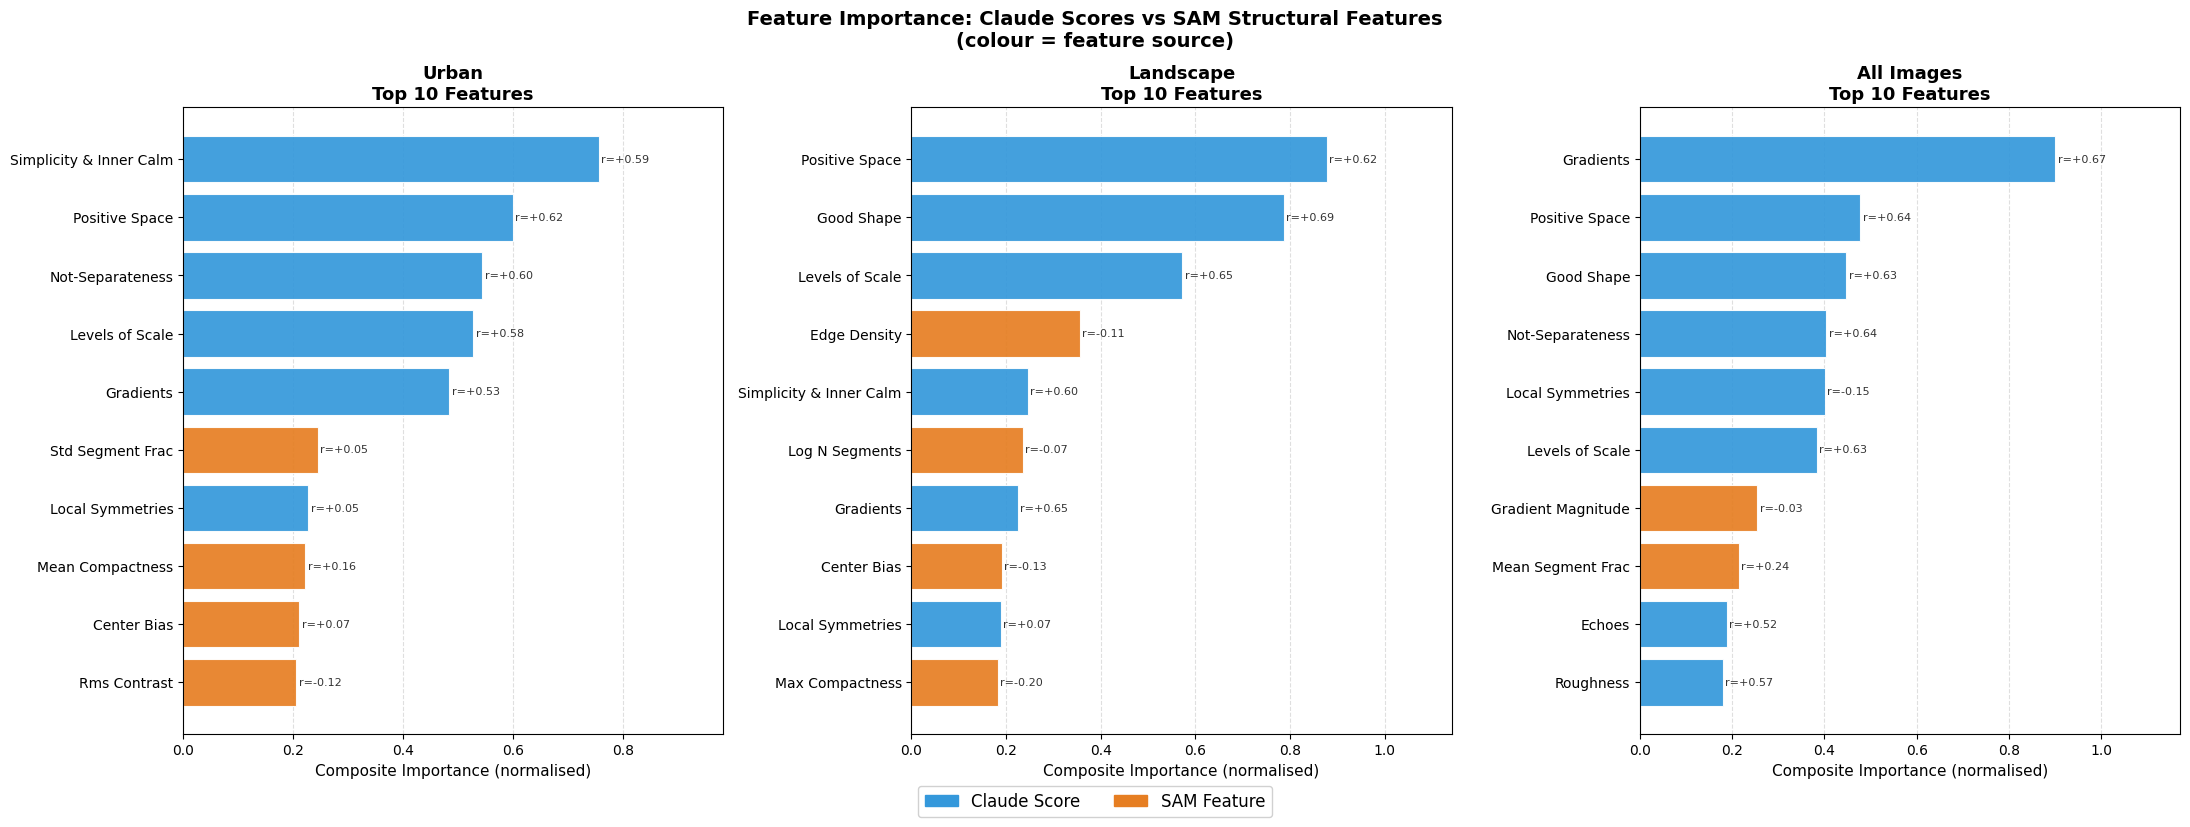

In [15]:
# ── Step 9: Visualise top 10 — Claude vs SAM coloured ───────

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
COLOR_CLAUDE = '#3498DB'
COLOR_SAM    = '#E67E22'
subset_titles = {'urban': 'Urban', 'landscape': 'Landscape', 'all': 'All Images'}

for ax, subset in zip(axes, ['urban', 'landscape', 'all']):
    top10  = results[subset].head(10)
    colors = [COLOR_SAM if s == 'SAM' else COLOR_CLAUDE for s in top10['Source'][::-1]]

    ax.barh(top10['Property'][::-1], top10['Composite'][::-1],
            color=colors, edgecolor='white', linewidth=0.8, alpha=0.92)

    for j, (_, row) in enumerate(top10[::-1].iterrows()):
        ax.text(row['Composite'] + 0.005, j,
                f"r={row['Pearson_r']:+.2f}",
                va='center', fontsize=8, color='#333333')

    ax.set_xlabel('Composite Importance (normalised)', fontsize=11)
    ax.set_title(f"{subset_titles[subset]}\nTop 10 Features", fontsize=13, fontweight='bold')
    ax.set_xlim(0, top10['Composite'].max() * 1.3)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

patch_c = mpatches.Patch(color=COLOR_CLAUDE, label='Claude Score')
patch_s = mpatches.Patch(color=COLOR_SAM,    label='SAM Feature')
fig.legend(handles=[patch_c, patch_s], fontsize=12, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.04), framealpha=0.9)

plt.suptitle('Feature Importance: Claude Scores vs SAM Structural Features\n'
             '(colour = feature source)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Capstone/feature_importance_sam_vs_claude.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — SAM vs Claude Correlation Heatmap


=== SAM Feature ↔ Claude Property Correlation Matrix ===



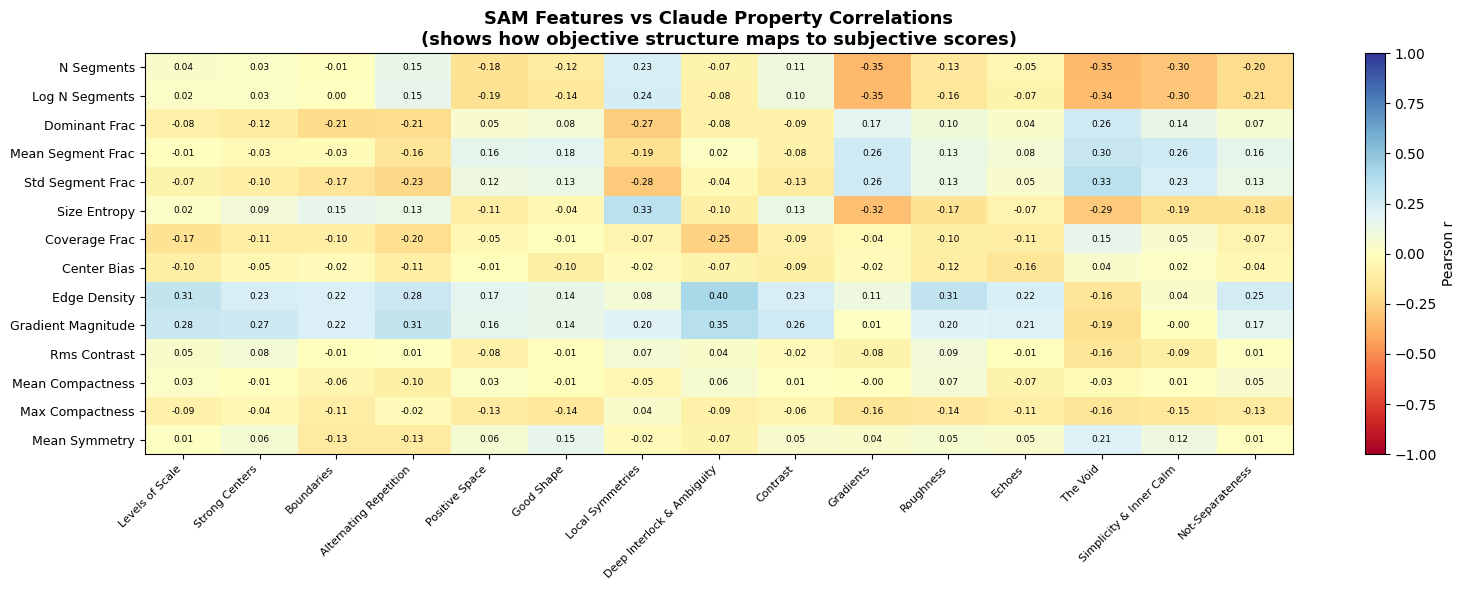


All done. Outputs saved to Capstone folder on Drive.


In [16]:
# ── Step 10: SAM features correlation with Claude properties ─

print("\n=== SAM Feature ↔ Claude Property Correlation Matrix ===\n")
corr_cross = df[sam_feats + claude_props].corr().loc[sam_feats, claude_props]
corr_cross.index = sam_pretty
corr_cross.columns = pretty_claude

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(corr_cross.values, cmap='RdYlBu', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(pretty_claude)))
ax.set_yticks(range(len(sam_pretty)))
ax.set_xticklabels(pretty_claude, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(sam_pretty, fontsize=9)
ax.set_title('SAM Features vs Claude Property Correlations\n'
             '(shows how objective structure maps to subjective scores)',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Pearson r')
for i in range(len(sam_pretty)):
    for j in range(len(pretty_claude)):
        v = corr_cross.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=6.5, color='white' if abs(v) > 0.6 else 'black')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Capstone/sam_claude_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nAll done. Outputs saved to Capstone folder on Drive.")